# SPACE2 clusters vs test CDRH3 RMSD

Links **SPACE2** structural clusters (full run, RMSD cutoff 1.25 Å) to test-set **`H_cdr3`** from checkpoint 5139 predictions.

**Note:** The ground-truth SPACE2 clustering was fit on **train + test GT** structures together, so those cluster IDs are not strictly test-blind.

**Analysis D** uses a separate clustering of **train GT + representative predicted test** structures (`outputs/train_plus_pred_test/`). Change `PRED_PATH` in `run_space2_train_plus_pred.sbatch` to use a different prediction directory.

**Outputs:** `outputs/` CSVs and `figures/` plots (also produced by `run_space2_cluster_performance_analysis.py`).

In [1]:
%matplotlib inline

import sys
from pathlib import Path

EVAL = Path("/opig-shared/users/lina4783/abb4_experiments/evaluation/space2_clustering")
sys.path.insert(0, str(EVAL))
assert EVAL.exists()

import matplotlib.pyplot as plt
import pandas as pd

import run_space2_cluster_performance_analysis as spa

plt.rcParams["figure.dpi"] = 120
SHOW_FIGURES = True

## 1. Load and merge

Cluster key: `space2_cluster_id = space2_cluster_by_length + "|" + space2_representative`

In [3]:
merged, space2_meta = spa.load_and_merge()
merged_s2 = spa.filter_space2_assigned(merged)
n_unassigned = len(merged) - len(merged_s2)
print(f"Test structures with metrics + SPACE2: {len(merged)}")
print(f"Excluded from SPACE2 analyses (no assignment): {n_unassigned}")
merged.head()

Test structures with metrics + SPACE2: 2243
Excluded from SPACE2 analyses (no assignment): 1


,pdb_name,H_cdr3,status,cluster_ids,split,space2_cluster_by_length,space2_representative,space2_cluster_id,n_train_space2_cluster,n_test_space2_cluster,n_total_space2_cluster,train_absent_space2,n_test_seq_cluster
0,pdb_00001kc5:H::L,0.754126,ok,3,test,14.0_9.0_9.0_11.0_8.0_9.0,pdb_00001kc5:H::L,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00001kc5:H::L,5,4,9,False,392
1,pdb_00001kcu:H::L,0.764006,ok,3,test,14.0_9.0_9.0_11.0_8.0_9.0,pdb_00001kc5:H::L,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00001kc5:H::L,5,4,9,False,392
2,pdb_00001e6o:H::L,2.267783,ok,7,test,13.0_10.0_13.0_10.0_8.0_8.0,pdb_00001e6o:H::L,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,2,2,True,5
3,pdb_00001e6j:H::L,2.542584,ok,7,test,13.0_10.0_13.0_10.0_8.0_8.0,pdb_00001e6o:H::L,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,2,2,True,5
4,pdb_00001fsk:F::E,2.920720,ok,3,test,13.0_10.0_11.0_11.0_8.0_9.0,pdb_00001fsk:F::E,13.0_10.0_11.0_11.0_8.0_9.0|pdb_00001fsk:F::E,0,4,4,True,392


In [3]:
cluster_stats = pd.read_csv(spa.CLUSTER_STATS_OUT)
cluster_stats.sort_values("n_total_space2_cluster", ascending=False).head(10)

,space2_cluster_id,n_train_space2_cluster,n_test_space2_cluster,n_total_space2_cluster
778,13.0_10.0_14.0_16.0_8.0_9.0|pdb_00009lr3:S1::S2,376,0,376
762,13.0_10.0_14.0_16.0_8.0_9.0|pdb_00007rkx:D1::D2,137,0,137
3242,13.0_10.0_14.0_10.0_8.0_9.0|pdb_00006adc:E::F,0,0,90
296,13.0_10.0_12.0_11.0_8.0_9.0|pdb_00007uh8:H::L,83,0,83
769,13.0_10.0_14.0_16.0_8.0_9.0|pdb_00008i97:H1::H2,78,0,78
131,13.0_10.0_11.0_11.0_8.0_9.0|pdb_00001zwi:A::B,76,0,76
2810,13.0_10.0_18.0_14.0_8.0_11.0|pdb_00006nfc:J::M,0,70,70
2001,13.0_9.0_13.0_11.0_8.0_9.0|pdb_00001yy8:D::C,69,0,69
498,13.0_10.0_13.0_11.0_8.0_9.0|pdb_00008spu:K1::K2,64,0,64
2685,13.0_10.0_15.0_11.0_8.0_9.0|pdb_00003ivk:H::L,0,56,56


### QA — unassigned SPACE2 (`nan|nan`)

Structures without SPACE2 output (mostly **single-chain**, never exported to the SPACE2 PDB pipeline; see [README](README.md)) get NaN cluster columns. String IDs become the synthetic bucket **`nan|nan`**. That bucket is **excluded** from SPACE2 cluster stats export and from analyses A/B/C below.

**Train + test** cluster size distribution uses only assigned structures.

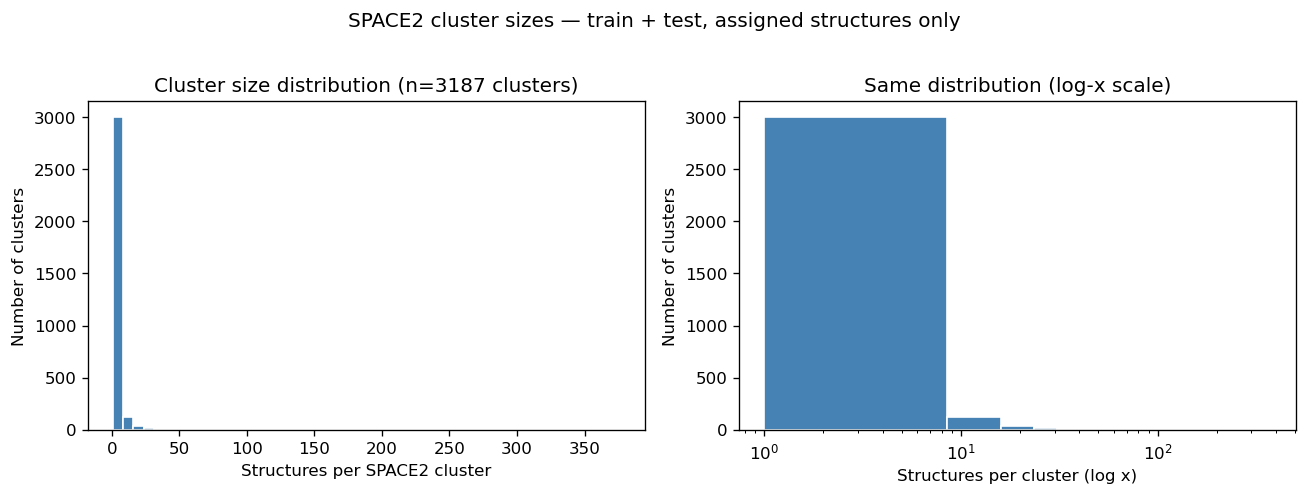

SPACE2 cluster sizes: excluded 3133 unassigned (22.2% of train+test metadata)


{'n_train_test_structures': 14141,
 'n_unassigned_excluded': 3133,
 'pct_unassigned': 22.15543455201188,
 'n_space2_clusters': 3187}

In [4]:
size_meta = spa.plot_space2_cluster_size_distribution(
    space2_meta,
    show_figures=SHOW_FIGURES,
)
size_meta

## 2. Analysis A — within-cluster homogeneity of test `H_cdr3`

Boxplots match [`evaluation_checks.ipynb`](../evaluation_checks.ipynb) (`mean_rmsds_clusters.png`): per-PDB mean CDRH3 from **all samples** (sequence `cluster_ids`) or test summary (SPACE2), clusters with **>2 PDB IDs**, sorted by cluster-mean RMSD, red dashed line at **2.5 Å**.

- **SPACE2:** groups with **`n_test > 2`**; x-axis **plot index** 1…N (sorted by mean CDRH3 RMSD; map in `outputs/space2_analysis_a_cluster_plot_index.csv`). **Tomato** = test-only, **light blue** = train overlap.
- **Baseline:** sequence **`cluster_ids`** via the notebook pipeline.
- **Kruskal–Wallis** on per-structure summary metrics (groups with `n_test > 2`).

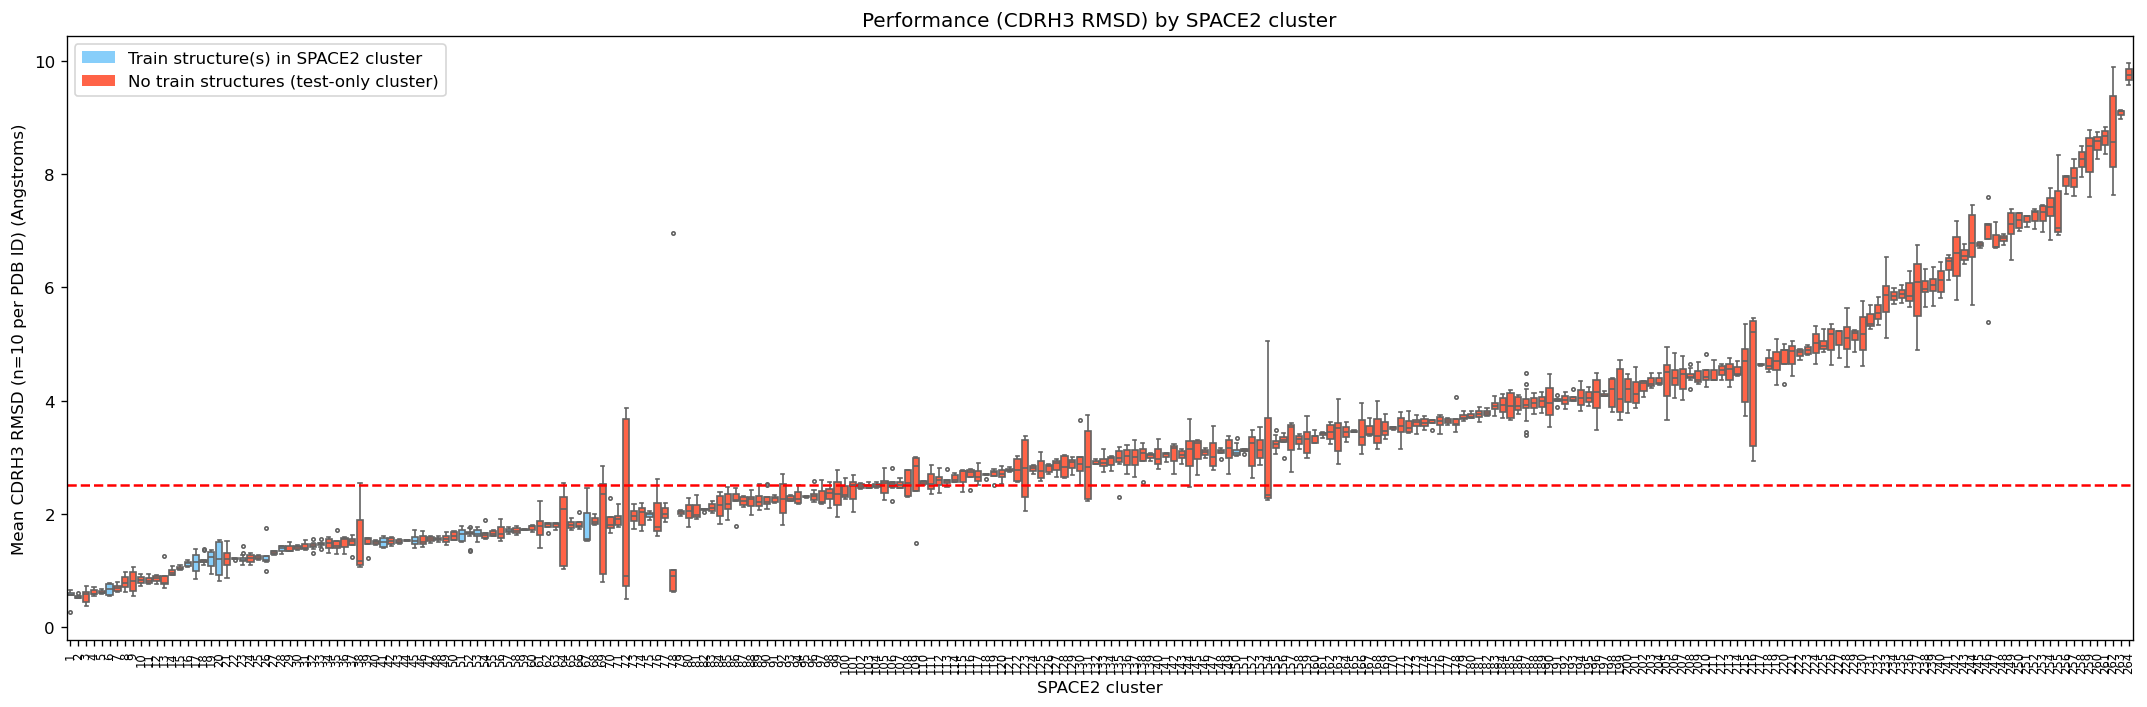

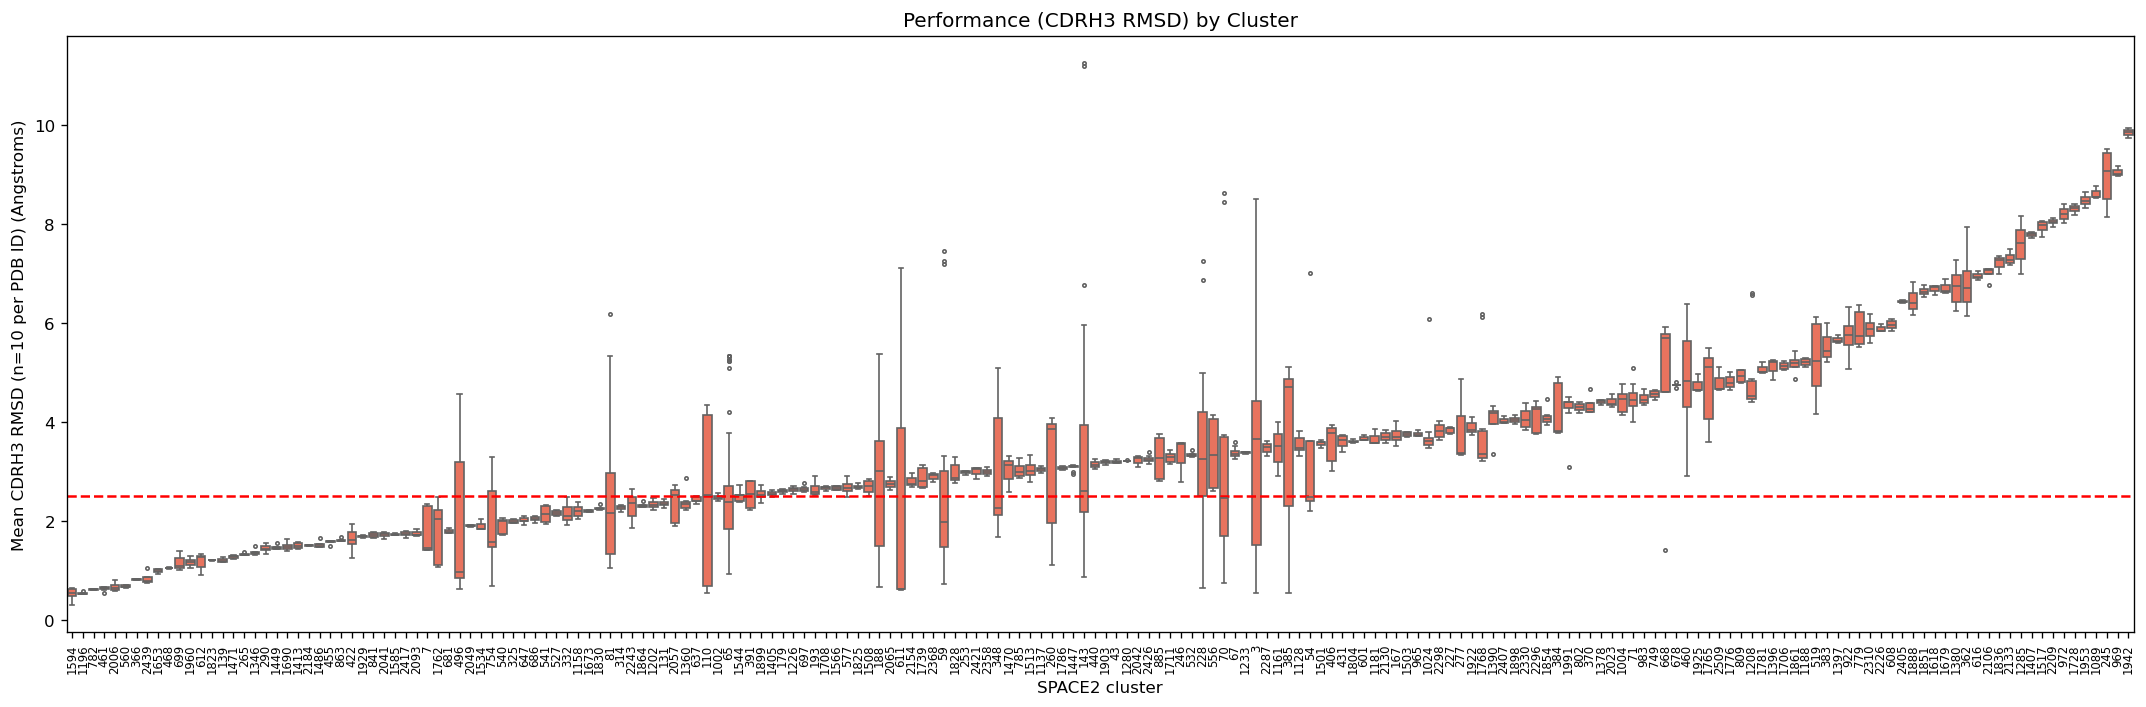

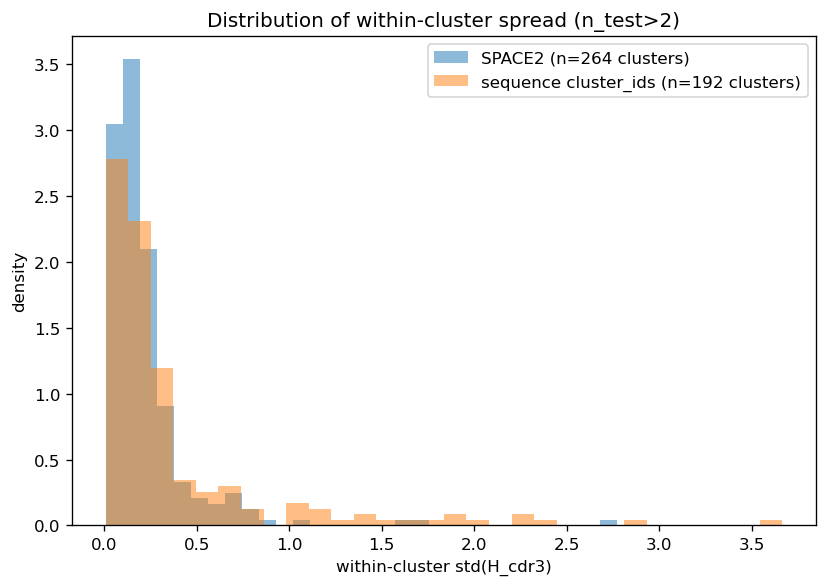

{'n_test_excluded_unassigned_space2': 1,
 'n_space2_clusters_plotted': 264,
 'n_seq_clusters_plotted': 192,
 'kruskal_space2_H': np.float64(1490.308820749532),
 'kruskal_space2_p': np.float64(2.6683447109234803e-170),
 'kruskal_seq_H': np.float64(1018.1194274318414),
 'kruskal_seq_p': np.float64(5.916956487094611e-113)}

In [5]:
a_meta = spa.analysis_a(merged, show_figures=SHOW_FIGURES)
a_meta

In [8]:
within_space2 = pd.read_csv(spa.WITHIN_SPACE2_OUT)
within_seq = pd.read_csv(spa.WITHIN_SEQ_OUT)
display(within_space2.loc[within_space2["n_test"] > 2].describe())
display(within_seq.loc[within_seq["n_test"] > 2].describe())

,n_test,mean,median,std,iqr,min,max,range,n_train_space2_cluster
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,5.848485,3.265053,3.262254,0.224669,0.243299,3.009698,3.530203,0.520505,0.212121
std,6.964860,1.869303,1.888029,0.263343,0.310947,1.814460,1.945018,0.594189,1.032037
min,3.000000,0.521189,0.511218,0.007022,0.006354,0.256984,0.600075,0.012708,0.000000
25%,3.000000,1.837093,1.790357,0.087994,0.086904,1.649165,2.081626,0.188867,0.000000
50%,4.000000,2.912624,2.894193,0.166728,0.160319,2.642627,3.145167,0.376652,0.000000
75%,6.000000,4.136341,4.124498,0.265265,0.265297,3.819791,4.491106,0.626203,0.000000
max,70.000000,9.768562,9.759242,2.770629,2.956912,9.582839,9.963605,6.359051,12.000000


,cluster_ids,n_test,mean,median,std,iqr,min,max,range
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,1188.208333,9.385417,3.497660,3.474690,0.381041,0.408945,3.054449,4.056380,1.001932
std,727.617707,30.339223,1.944821,1.987645,0.542588,0.592621,1.976267,2.216937,1.593957
min,3.000000,3.000000,0.519596,0.511218,0.007022,0.006354,0.256984,0.600075,0.012708
25%,525.000000,3.000000,2.164476,2.069323,0.101586,0.092203,1.601116,2.532178,0.236748
50%,1217.000000,4.000000,3.119048,3.141729,0.184016,0.175732,2.697986,3.681563,0.426502
75%,1825.750000,7.000000,4.362655,4.434238,0.343674,0.422179,3.850786,5.232054,0.888084
max,2509.000000,392.000000,9.768562,9.759242,3.665271,3.179525,9.582839,11.271516,10.480394


## 3. Analysis B — train overlap vs test `H_cdr3`

For each test structure, **`n_train_space2_cluster`** = number of **train** structures in the same SPACE2 cluster (from full metadata). Mirrors [`cluster_train_coverage`](../cluster_train_coverage/run_analysis.py) but with structural clusters.

**Summary table:** each row is a different test (correlation vs Mann–Whitney). Unused columns are **NaN by design**, not failed stats.

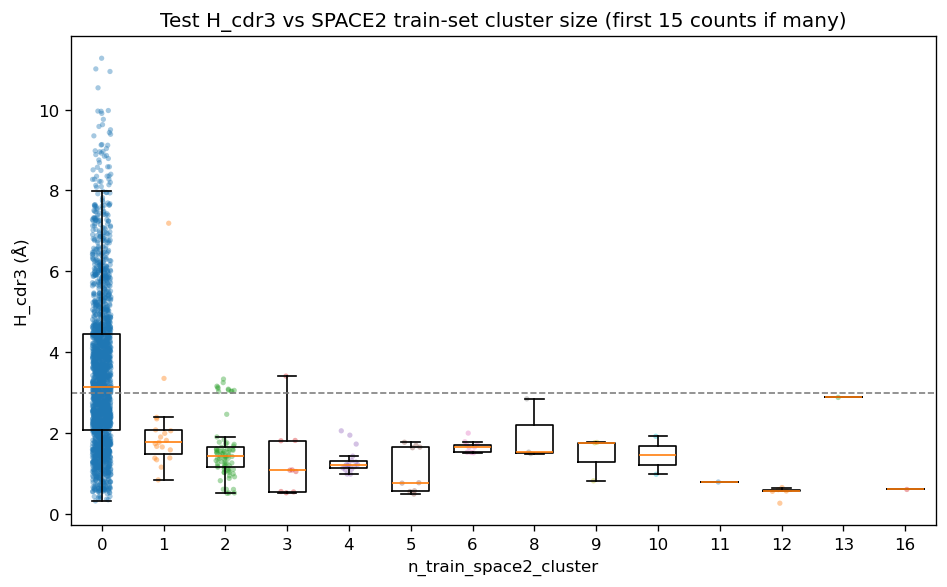

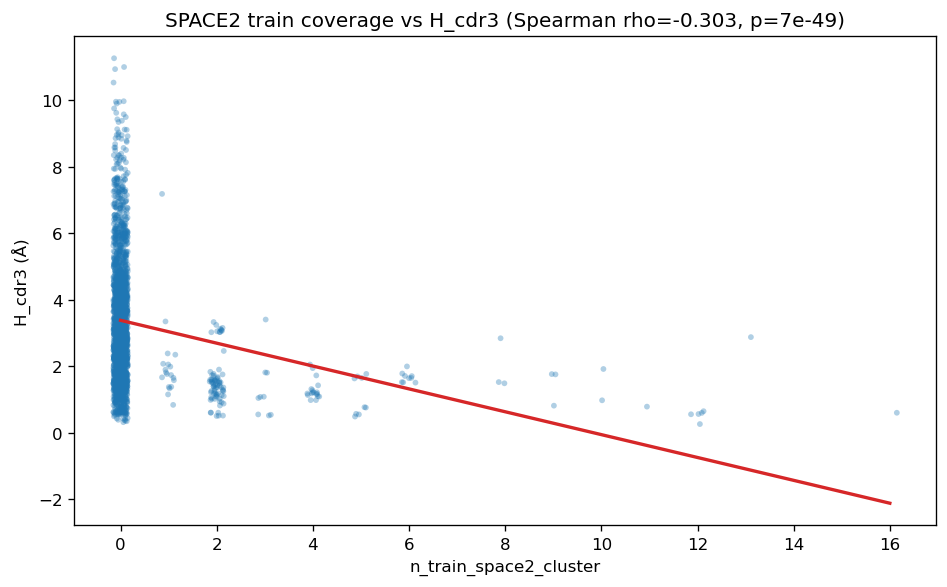

,cluster_type,level,pearson_r,pearson_p,spearman_rho,spearman_p,n,slope,intercept,r2,adj_r2,r2_percent,p_value,mannwhitney_u,mannwhitney_p,median_n0,median_n_gt0
0,space2,per_sample,-0.212649,2.437539e-24,-0.303171,7.017540e-49,2242,-0.344196,3.380845,0.045220,0.044793,4.521973,2.437539e-24,NaN,NaN,NaN,NaN
1,space2,per_cluster_median,-0.205487,9.300238e-09,-0.313921,5.296392e-19,767,-0.280760,3.393140,0.042225,0.040973,4.222480,9.300238e-09,NaN,NaN,NaN,NaN
2,space2,mannwhitney_n_train_0_vs_gt0,NaN,NaN,NaN,NaN,2242,NaN,NaN,NaN,NaN,NaN,NaN,275527.0,2.199916e-46,3.125009,1.423733


In [9]:
b_stats = spa.analysis_b(merged, show_figures=SHOW_FIGURES)
display(pd.DataFrame(b_stats))

## 4. Analysis C — train-absent (test-only) SPACE2 clusters

Compare test **`H_cdr3`** for structures in clusters with **no train members** vs clusters with train coverage. We do **not** regress `H_cdr3` on total cluster size (`n_total`) here — train coverage is already covered in Analysis B.

Again, sparse NaNs in the combined export mean “not applicable for this row type.”

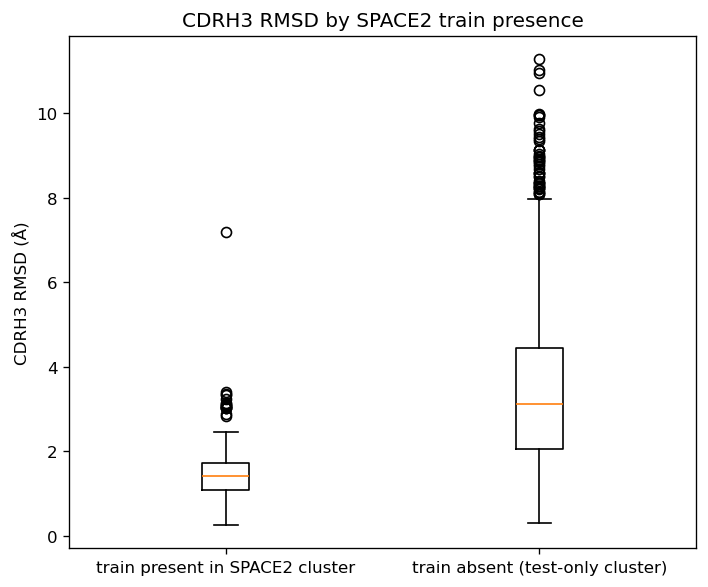

,cluster_type,level,n_absent,n_present,median_absent,median_present,mannwhitney_u,mannwhitney_p,n_clusters,n_test_structures
0,space2,train_absent_vs_present_structures,2085.0,157.0,3.125009,1.423733,275527.0,2.199916e-46,NaN,NaN
1,space2,test_only_space2_cluster_count,NaN,NaN,NaN,NaN,NaN,NaN,706.0,2085.0


In [4]:
c_stats = spa.analysis_c(merged, show_figures=SHOW_FIGURES)
display(pd.DataFrame(c_stats))

## 5. Combined correlation / test summary

Wide CSV for reuse; **prefer the B and C tables above** when reading results. Stacking rows fills irrelevant fields with NaN (e.g. Mann–Whitney rows have no Pearson `r`).

In [ ]:
summary = pd.DataFrame(b_stats + c_stats)
summary.to_csv(spa.CORR_SUMMARY_OUT, index=False)
summary

,cluster_type,level,pearson_r,pearson_p,spearman_rho,spearman_p,n,slope,intercept,r2,...,mannwhitney_u,mannwhitney_p,median_n0,median_n_gt0,n_absent,n_present,median_absent,median_present,n_clusters,n_test_structures
0,space2,per_sample,-0.212649,2.437539e-24,-0.303171,7.017540e-49,2242.0,-0.344196,3.380845,0.045220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,space2,per_cluster_median,-0.205487,9.300238e-09,-0.313921,5.296392e-19,767.0,-0.280760,3.393140,0.042225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,space2,mannwhitney_n_train_0_vs_gt0,NaN,NaN,NaN,NaN,2242.0,NaN,NaN,NaN,...,275527.0,2.199916e-46,3.125009,1.423733,NaN,NaN,NaN,NaN,NaN,NaN
3,space2,train_absent_vs_present_structures,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,275527.0,2.199916e-46,NaN,NaN,2085.0,157.0,3.125009,1.423733,NaN,NaN
4,space2,test_only_space2_cluster_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,706.0,2085.0


Figures render **inline** when analysis cells run (`SHOW_FIGURES=True`) and are also saved under `figures/` (including `space2_cluster_size_distribution_train_test.png`). Analysis D figures appear after the predicted-test clustering job finishes.

## 5. Analysis D — predicted vs GT train-cluster overlap

Does the model place test predictions into SPACE2 clusters that already contain **training** structures more often than the **ground-truth** test structures do?

This uses a **separate** clustering (`outputs/train_plus_pred_test/`): train GT PDBs + the representative predicted test PDB (`representative_sample` in the metrics summary). Cluster IDs are not comparable to the GT run; the comparable quantity is the per-structure flag “shares a cluster with ≥1 train structure.”

Rates are computed on the **intersection** of test `pdb_name`s assigned in both clusterings. McNemar tests the paired difference. The GT-novel slice (`shares_train_gt == False`) asks how often a prediction of a structurally novel test antibody still lands in a train-occupied cluster.

Requires `run_space2_train_plus_pred.sbatch` to have finished.

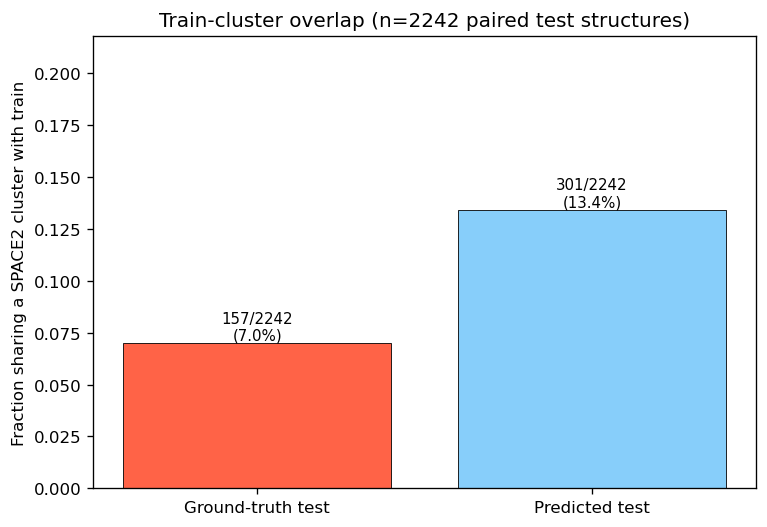

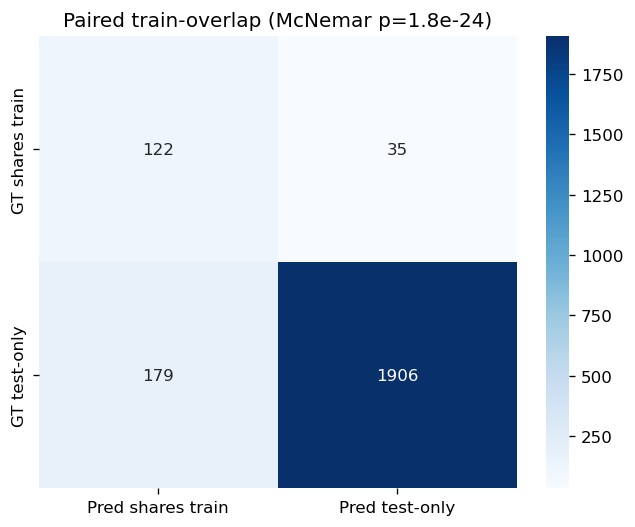

Analysis D: {
  "n_paired_test": 2242,
  "n_gt_share_train": 157,
  "n_pred_share_train": 301,
  "frac_gt_share_train": 0.07002676181980375,
  "frac_pred_share_train": 0.13425512934879572,
  "n_both_share": 122,
  "n_neither_share": 1906,
  "n_gt_only": 35,
  "n_pred_only": 179,
  "n_gt_novel": 2085,
  "n_gt_novel_pred_shares_train": 179,
  "frac_gt_novel_pred_shares_train": 0.08585131894484413,
  "mcnemar_n_discordant": 214,
  "mcnemar_stat": 95.55607476635514,
  "mcnemar_p": 1.7609179222437123e-24,
  "chi2_p_continuity": 1.437610345600485e-22
}
Saved per-structure table: /opig-shared/users/lina4783/abb4_experiments/evaluation/space2_clustering/outputs/space2_pred_vs_gt_train_overlap.csv


n_paired_test                      2.242000e+03
n_gt_share_train                   1.570000e+02
n_pred_share_train                 3.010000e+02
frac_gt_share_train                7.002676e-02
frac_pred_share_train              1.342551e-01
n_both_share                       1.220000e+02
n_neither_share                    1.906000e+03
n_gt_only                          3.500000e+01
n_pred_only                        1.790000e+02
n_gt_novel                         2.085000e+03
n_gt_novel_pred_shares_train       1.790000e+02
frac_gt_novel_pred_shares_train    8.585132e-02
mcnemar_n_discordant               2.140000e+02
mcnemar_stat                       9.555607e+01
mcnemar_p                          1.760918e-24
chi2_p_continuity                  1.437610e-22
dtype: float64

,pdb_name,space2_cluster_id_gt,n_train_gt,shares_train_gt,space2_cluster_id_pred,n_train_pred,shares_train_pred
0,pdb_00001kc5:H::L,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00001kc5:H::L,5,True,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00005gs0:H::L,5,True
1,pdb_00001kcu:H::L,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00001kc5:H::L,5,True,14.0_9.0_9.0_11.0_8.0_9.0|pdb_00005gs0:H::L,5,True
2,pdb_00001e6o:H::L,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,False,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,False
3,pdb_00001e6j:H::L,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,False,13.0_10.0_13.0_10.0_8.0_8.0|pdb_00001e6o:H::L,0,False
4,pdb_00001fsk:F::E,13.0_10.0_11.0_11.0_8.0_9.0|pdb_00001fsk:F::E,0,False,13.0_10.0_11.0_11.0_8.0_9.0|pdb_00005t0y:I::G,4,True


In [6]:
paired, d_summary = spa.analysis_d(gt_meta=space2_meta, show_figures=SHOW_FIGURES)
print(f"Saved per-structure table: {spa.PRED_VS_GT_OVERLAP_OUT}")
display(pd.Series(d_summary))
paired.head()

## 6. Pre-clustering CDR-length group overlap

SPACE2 first groups structures by identical six-CDR length signatures (`space2_cluster_by_length`) and performs RMSD clustering **within** each group. A test structure in a test-only length group can never share a train/test structural cluster with train.

This section reports the pre-clustering ceiling: fraction of assigned test structures whose CDR-length group is also present in assigned train structures.

- `source == "gt"`: `outputs/full/metadata_with_space2.csv` (train GT + test GT clustering)
- `source == "pred"`: `outputs/train_plus_pred_test/metadata_with_space2.csv` (train GT + representative predicted test clustering; if available)

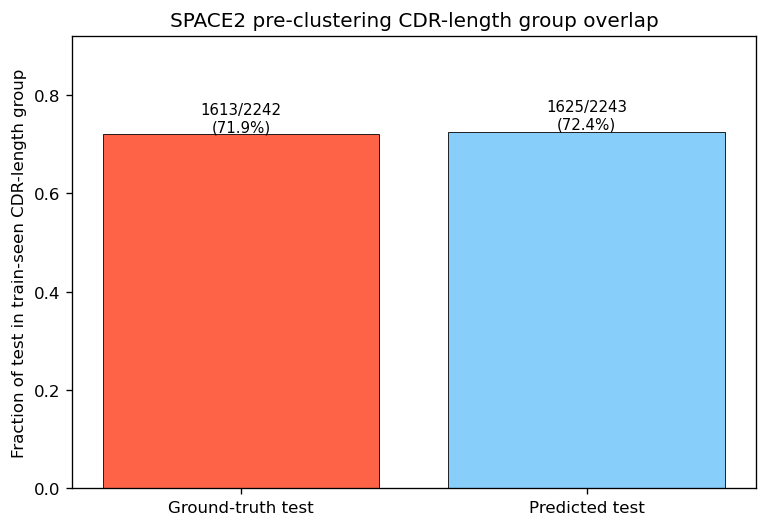

Analysis E (length-group overlap): [
  {
    "source": "gt",
    "n_assigned_test_structures": 2242,
    "n_test_in_train_length_group": 1613,
    "frac_test_in_train_length_group": 0.7194469223907226,
    "n_test_not_in_train_length_group": 629,
    "n_train_length_groups": 800,
    "n_test_length_groups": 397,
    "n_shared_length_groups": 220,
    "n_test_only_length_groups": 177
  },
  {
    "source": "pred",
    "n_assigned_test_structures": 2243,
    "n_test_in_train_length_group": 1625,
    "frac_test_in_train_length_group": 0.72447614801605,
    "n_test_not_in_train_length_group": 618,
    "n_train_length_groups": 800,
    "n_test_length_groups": 396,
    "n_shared_length_groups": 219,
    "n_test_only_length_groups": 177
  }
]
Saved length-group summary: /opig-shared/users/lina4783/abb4_experiments/evaluation/space2_clustering/outputs/space2_length_group_train_overlap.csv


,source,n_assigned_test_structures,n_test_in_train_length_group,frac_test_in_train_length_group,n_test_not_in_train_length_group,n_train_length_groups,n_test_length_groups,n_shared_length_groups,n_test_only_length_groups
0,gt,2242,1613,0.719447,629,800,397,220,177
1,pred,2243,1625,0.724476,618,800,396,219,177


source  in_train_length_group
gt      False                     629
        True                     1613
pred    False                     618
        True                     1625
Name: n_test_structures, dtype: int64

In [4]:
length_test_df, length_summary = spa.analysis_length_group_train_overlap(
    gt_meta=space2_meta,
    show_figures=SHOW_FIGURES,
)
print(f"Saved length-group summary: {spa.LENGTH_GROUP_OVERLAP_OUT}")

display(length_summary)

display(
    length_test_df.groupby(["source", "in_train_length_group"]).size().rename("n_test_structures")
)